In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

from _helper_functions import *


In [4]:
# newly tested variants forming the test set
testlistdf=pd.read_csv('variant-labels.txt',sep='\t')
testlistdf['name']=[i.replace('OSL','ORL') for i in testlistdf['name']]
testlist=[i for i in testlistdf['name'].tolist()]

In [5]:
c2f={
'b6.5':list,
'a6.5':list,
'a6.7':list,
'B-line':list,
'A-line':list,
 }

sdf=pd.read_csv('S12-broad-annotations_value.csv').set_index('col_celltype')
ylabel='exp-cells'

sdf=pd.read_csv('S12-broad-annotations_percent.csv').set_index('col_celltype')
ylabel='pct-cells'

sdf.columns=[c.split('(')[0] for c in sdf.columns]
sdf=sdf.transpose().reset_index()
sdf=sdf.merge(testlistdf,left_on='index',right_on='name')
sdf=sdf.loc[sdf['index'].isin(testlist),:]

sdf=sdf.groupby('prediction').agg(c2f)

c2v={c:[] for c in ['tissue','value','Syntax']}
for tis in c2f:
    for syn in ['moderate','robust']:
        for val in sdf.at[syn,tis]:
            
            c2v['tissue'].append(tis)
            c2v['value'].append(val)
            c2v['Syntax'].append(syn)

    
plotdf=pd.DataFrame(c2v)

In [6]:
mods=plotdf['Syntax']=='moderate'
robs=plotdf['Syntax']=='robust'
ines=plotdf['Syntax']=='inert'

In [7]:
robs=plotdf['Syntax']=='robust'
A=(plotdf['tissue']=='A-line')      & robs
B=(plotdf['tissue']=='B-line')  & robs

_,p=stats.ttest_ind(plotdf.loc[A,'value'],plotdf.loc[B,'value'])
print('A vs B',round(p,5))


A vs B 6e-05


/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/874683919.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])
/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/874683919.py:7: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])


Text(0.5, 6.583333333333323, '')

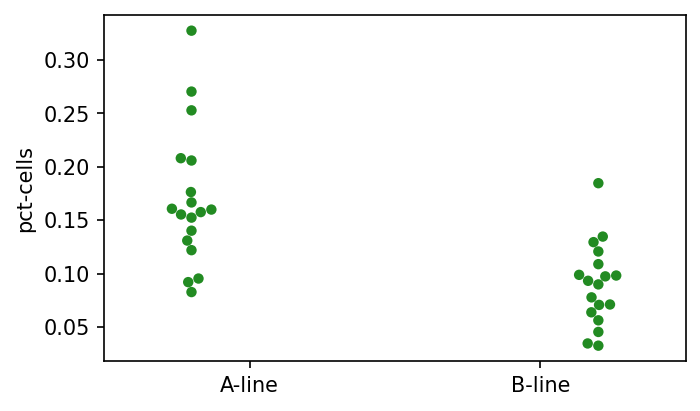

In [8]:
order=[ 
'A-line',
'B-line',
]
    
fig,ax=quickfig(5,3)
sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])

ax.set_ylabel(ylabel)
ax.set_xlabel('')

In [9]:
robs=plotdf['Syntax']=='robust'
A=(plotdf['tissue']=='A-line')      & robs
a67=(plotdf['tissue']=='a6.7')  & robs

_,p=stats.ttest_ind(plotdf.loc[A,'value'],plotdf.loc[a67,'value'])
print('A vs a67',round(p,5))


A vs a67 0.00565


A-line 3e-05
a6.7 0.00051


/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/2886010170.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])
/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/2886010170.py:14: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])


Text(0.5, 6.583333333333323, '')

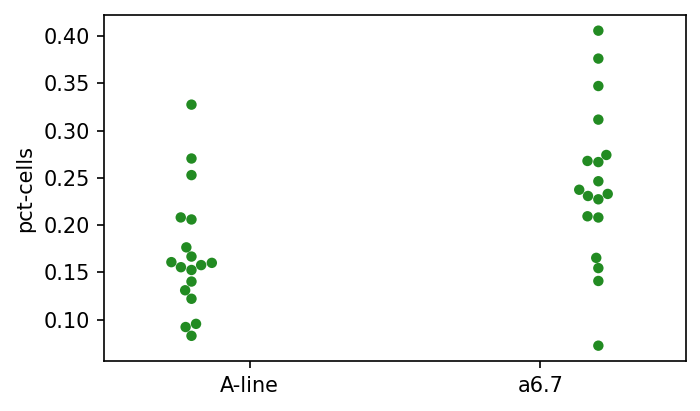

In [10]:
order=[ 
'A-line',
'a6.7',
]

for oi in order:
    
    thisdf=plotdf.loc[plotdf['tissue']==oi,:]
    _,p = stats.mannwhitneyu(thisdf.loc[mods,'value'], 
                                thisdf.loc[robs,'value'])
    print(oi,round(p,5))

fig,ax=quickfig(5,3)
sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])

ax.set_ylabel(ylabel)
ax.set_xlabel('')

In [11]:
robs=plotdf['Syntax']=='robust'
a65=(plotdf['tissue']=='a6.5')      & robs
b65=(plotdf['tissue']=='b6.5')      & robs
a67=(plotdf['tissue']=='a6.7')  & robs

_,p=stats.ttest_ind(plotdf.loc[b65,'value'],plotdf.loc[a67,'value'])
print('b65 vs a67',round(p,6))

_,p=stats.ttest_ind(plotdf.loc[a65,'value'],plotdf.loc[a67,'value'])
print('a65 vs a67',round(p,5))


b65 vs a67 0.0
a65 vs a67 0.0


/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/2951665443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])
/var/folders/w_/c5c_656n15798dlm00g7fp6r0000gn/T/ipykernel_4567/2951665443.py:9: UserWarning: 
The palette list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])


Text(0.5, 6.583333333333323, '')

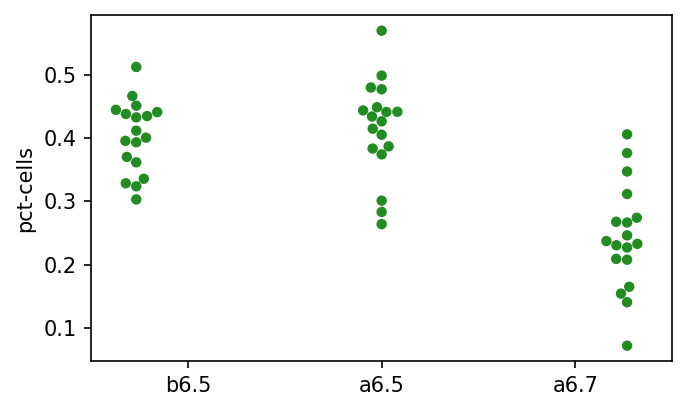

In [12]:
order=[ 
'b6.5',
'a6.5',
'a6.7',
]


fig,ax=quickfig(5,3)
sns.swarmplot(data=plotdf.loc[plotdf['Syntax']=='robust',:],order=order,x='tissue',y='value',dodge=True,palette=['forestgreen'])

ax.set_ylabel(ylabel)
ax.set_xlabel('')